In [23]:
import sys
sys.path.append("../src")

import GOenrichment as ge
import importlib

importlib.reload(ge)


<module 'GOenrichment' from 'c:\\Users\\haina\\Desktop\\BIO_RA\\notebooks\\../src\\GOenrichment.py'>

Proneural: BP UP
Proneural: BP DOWN
Proneural: CC UP
Proneural: CC DOWN
Proneural: MF UP
Proneural: MF DOWN


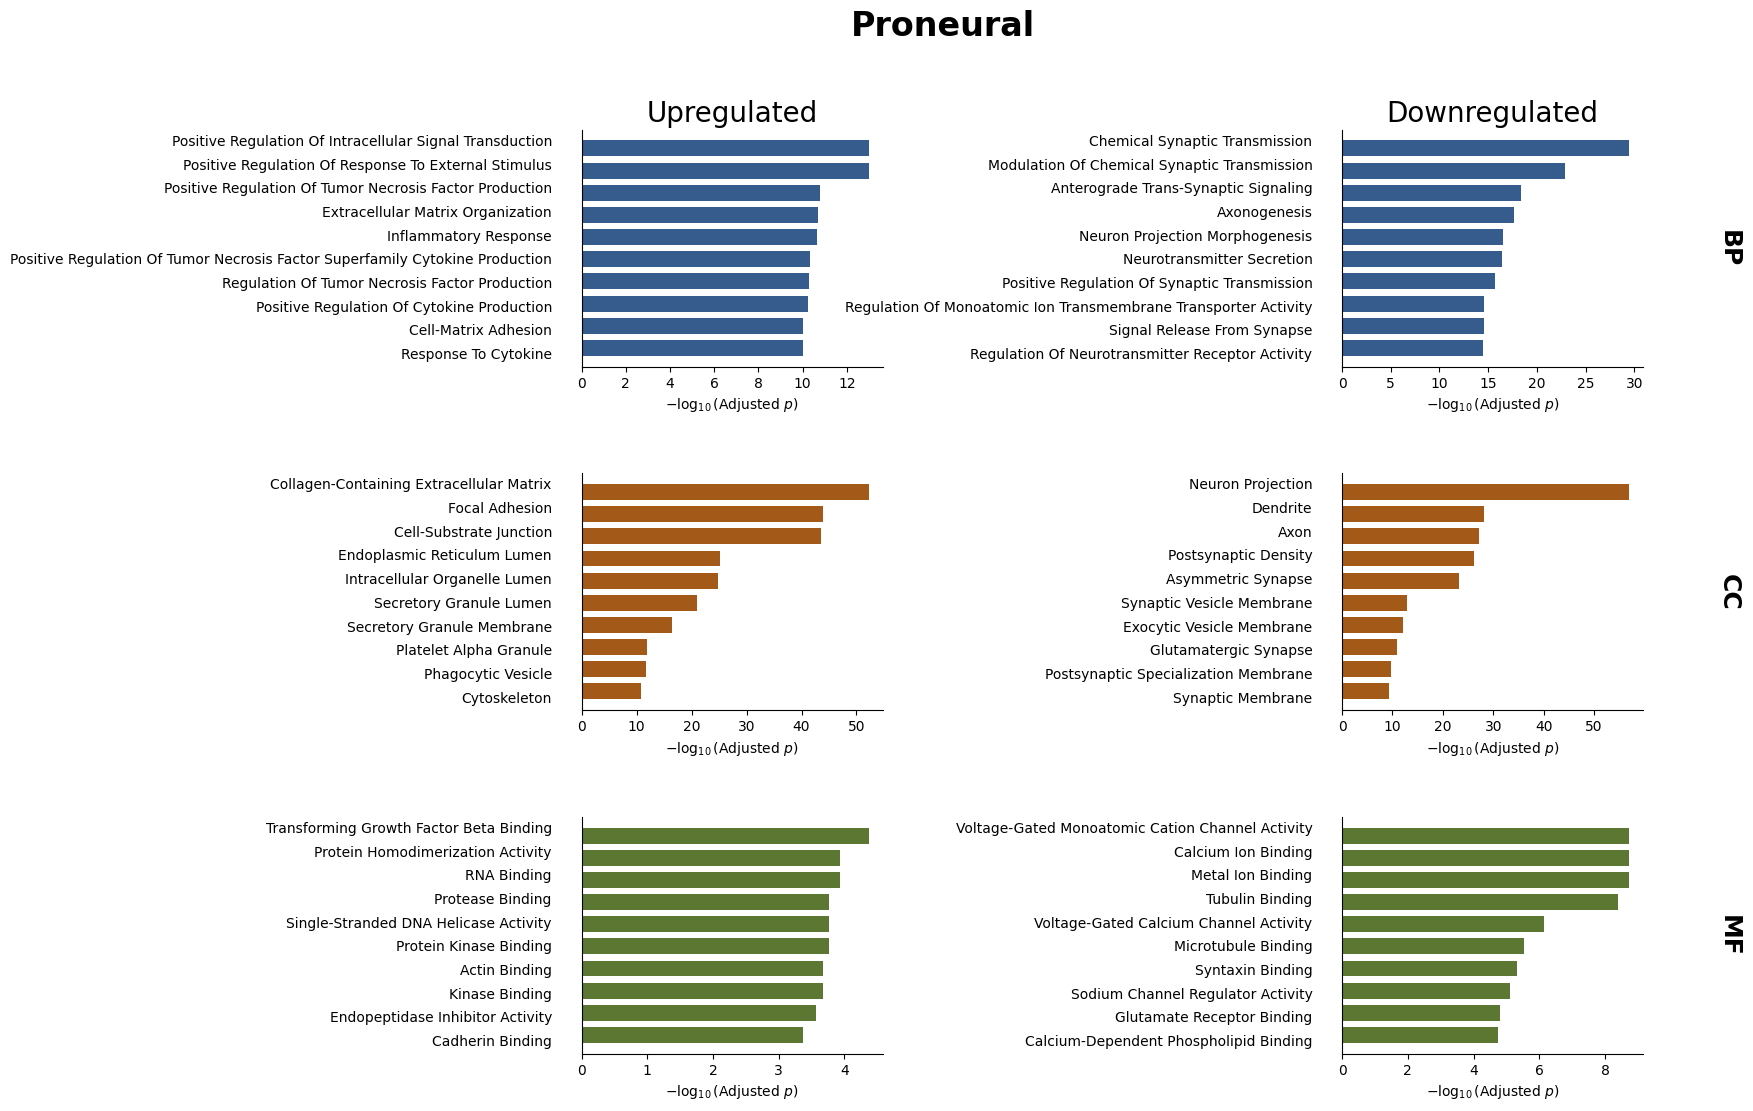

Classical: BP UP
Classical: BP DOWN
Classical: CC UP
Classical: CC DOWN
Classical: MF UP
Classical: MF DOWN


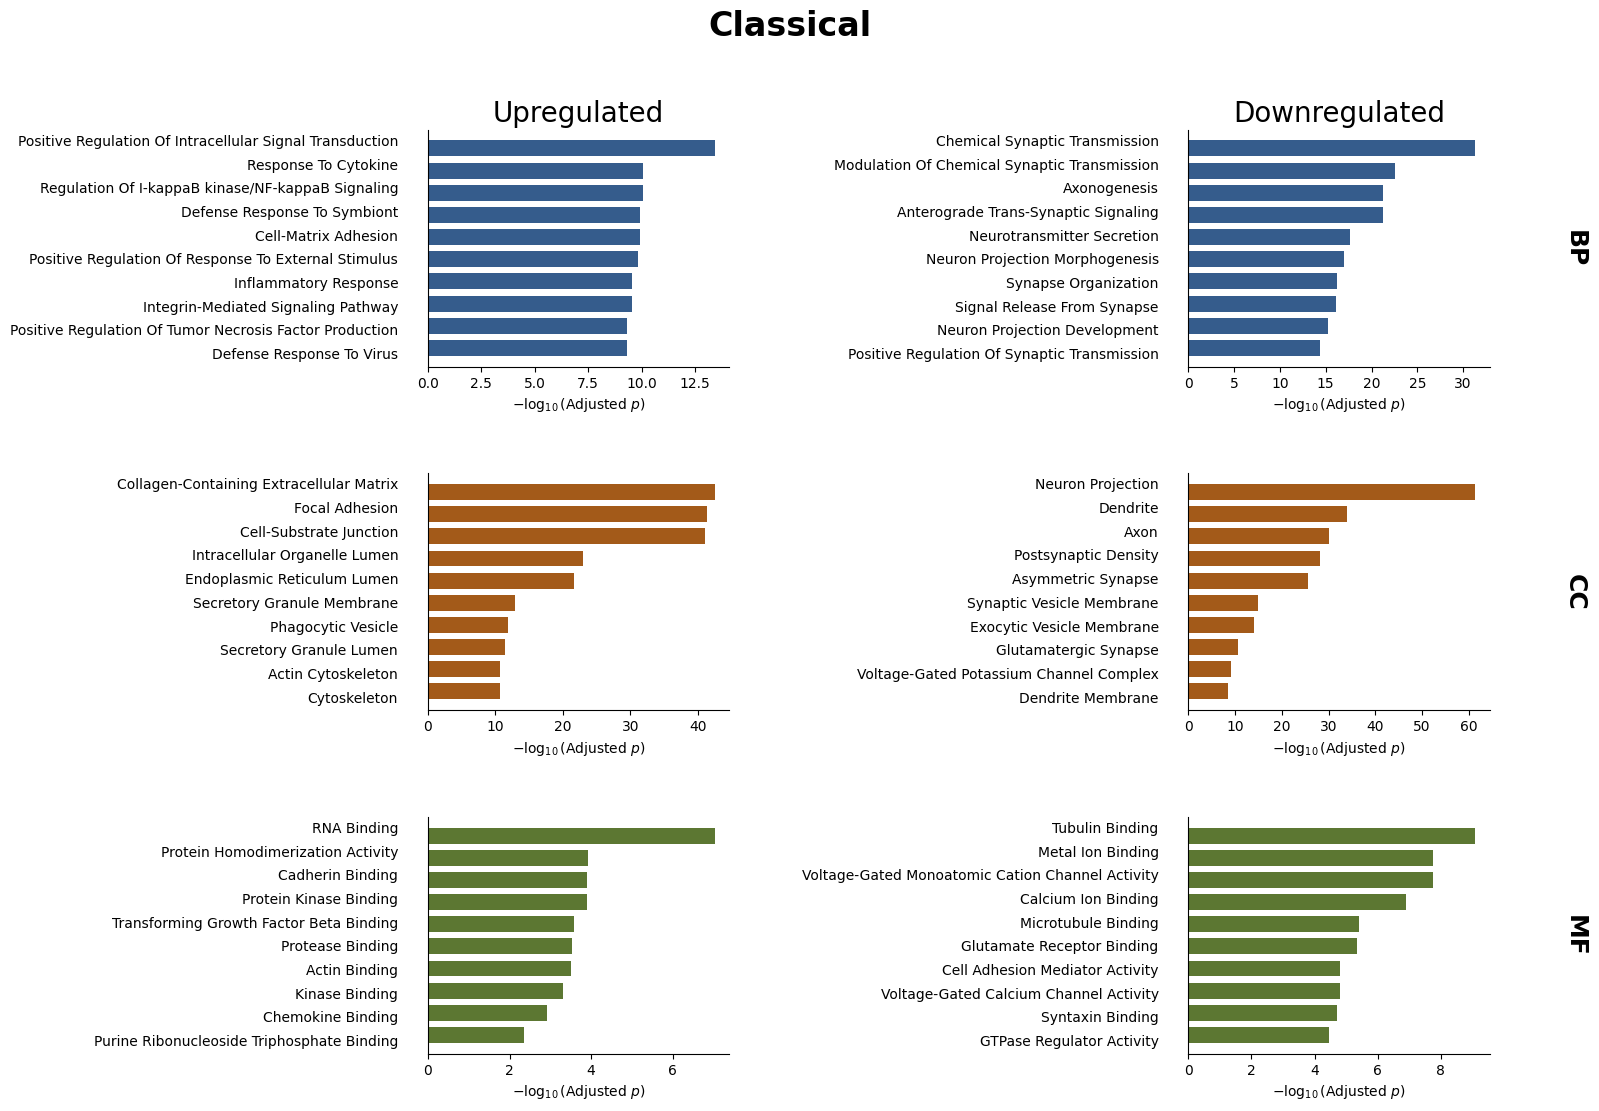

Mesenchymal: BP UP
Mesenchymal: BP DOWN
Mesenchymal: CC UP
Mesenchymal: CC DOWN
Mesenchymal: MF UP
Mesenchymal: MF DOWN


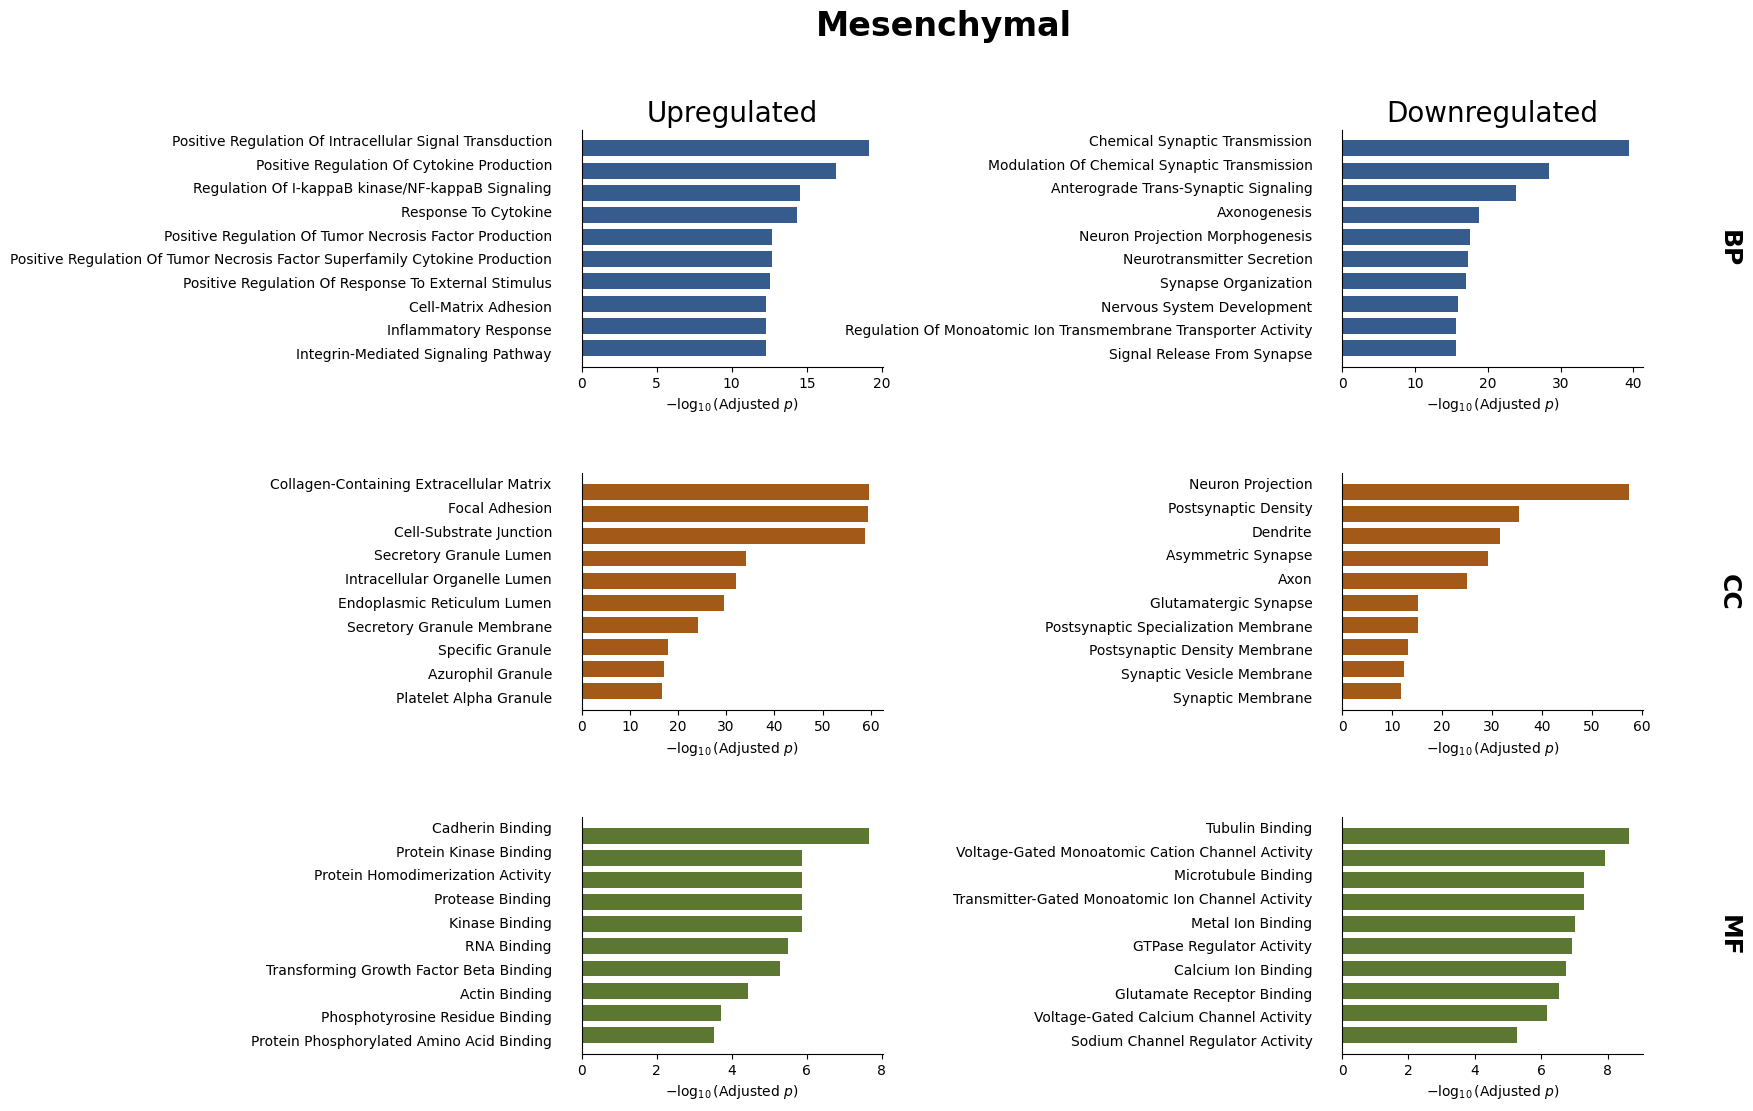

IDH: BP UP
IDH: BP DOWN
IDH: CC UP
IDH: CC DOWN
IDH: MF UP
IDH: MF DOWN


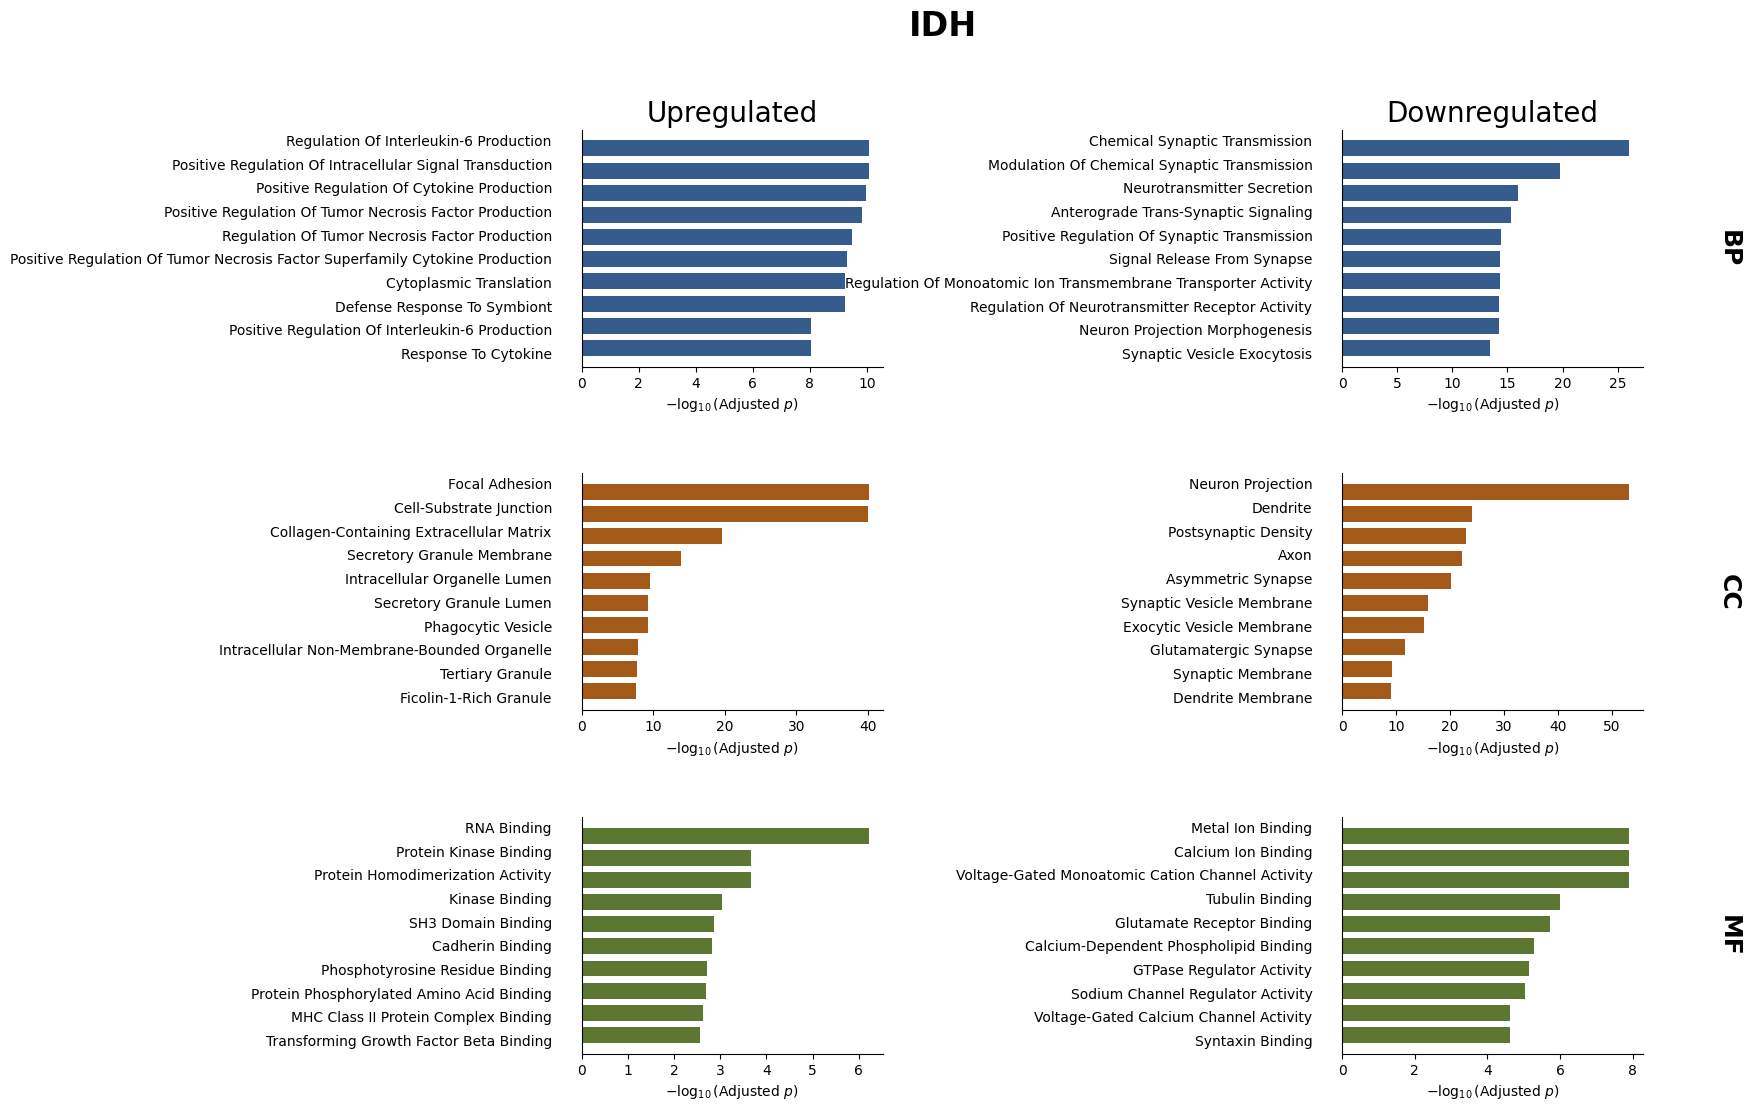

In [24]:
files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv",
    "IDH": "../data/interim/idh_rna_diff.csv"
}

for subtype, file in files.items():
    ge.analyze_subtype(file, subtype)

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gseapy as gp

# -----------------------------
# USER SETTINGS
# -----------------------------
PVAL_COLUMN = "pvalue"      # change if necessary
LOGFC_COLUMN = "log2FC"         # change if necessary
GENE_COLUMN = "gene_name"    # change if necessary

PVAL_THRESHOLD = 0.05
LOGFC_THRESHOLD = 1

TOP_N = 10

KEGG_LIBRARY = "KEGG_2021_Human"


def run_kegg(gene_list):

    if len(gene_list) == 0:
        return pd.DataFrame()

    enr = gp.enrichr(
        gene_list=gene_list,
        gene_sets=KEGG_LIBRARY,
        organism="human",
        outdir=None
    )

    df = enr.results.copy()

    df = df.sort_values("Adjusted P-value")

    return df.head(TOP_N)


def plot_kegg(up_results, down_results, title):

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(18, 8),
        constrained_layout=True
    )

    colors = {
        "Upregulated": "#355C8C",
        "Downregulated": "#9A5316"
    }

    for ax, df, heading in zip(
        axes,
        [up_results, down_results],
        ["Upregulated", "Downregulated"]
    ):

        if df.empty:
            ax.text(
                0.5,
                0.5,
                "No enriched pathways",
                ha="center",
                va="center",
                fontsize=14
            )
            ax.axis("off")
            continue

        df = df.copy()

        # Remove species name from pathway names
        df["Term"] = df["Term"].str.replace(
            r"\s*Homo sapiens.*",
            "",
            regex=True
        )

        # Plot most significant on top
        df = df.sort_values("Adjusted P-value", ascending=True)

        df["score"] = -np.log10(df["Adjusted P-value"])

        ax.barh(
            df["Term"],
            df["score"],
            color=colors[heading],
            height=0.75
        )

        ax.invert_yaxis()

        ax.set_xlabel(r"$-\log_{10}$(Adjusted p-value)", fontsize=11)

        ax.set_title(heading, fontsize=16)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.tick_params(axis="y", labelsize=10)

    fig.suptitle(title, fontsize=20)

    plt.show()


def analyze_subtype_kegg(csv_file, subtype_name):

    df = pd.read_csv(csv_file)

    sig = df[
        (df[PVAL_COLUMN] < PVAL_THRESHOLD)
        &
        (abs(df[LOGFC_COLUMN]) > LOGFC_THRESHOLD)
    ]

    up = sig[sig[LOGFC_COLUMN] > 0]
    down = sig[sig[LOGFC_COLUMN] < 0]

    up_genes = up[GENE_COLUMN].dropna().unique().tolist()
    down_genes = down[GENE_COLUMN].dropna().unique().tolist()

    print(f"{subtype_name}: KEGG UP")
    up_results = run_kegg(up_genes)

    print(f"{subtype_name}: KEGG DOWN")
    down_results = run_kegg(down_genes)

    plot_kegg(
        up_results,
        down_results,
        f"{subtype_name} KEGG Enrichment"
    )

Proneural: KEGG UP
Proneural: KEGG DOWN


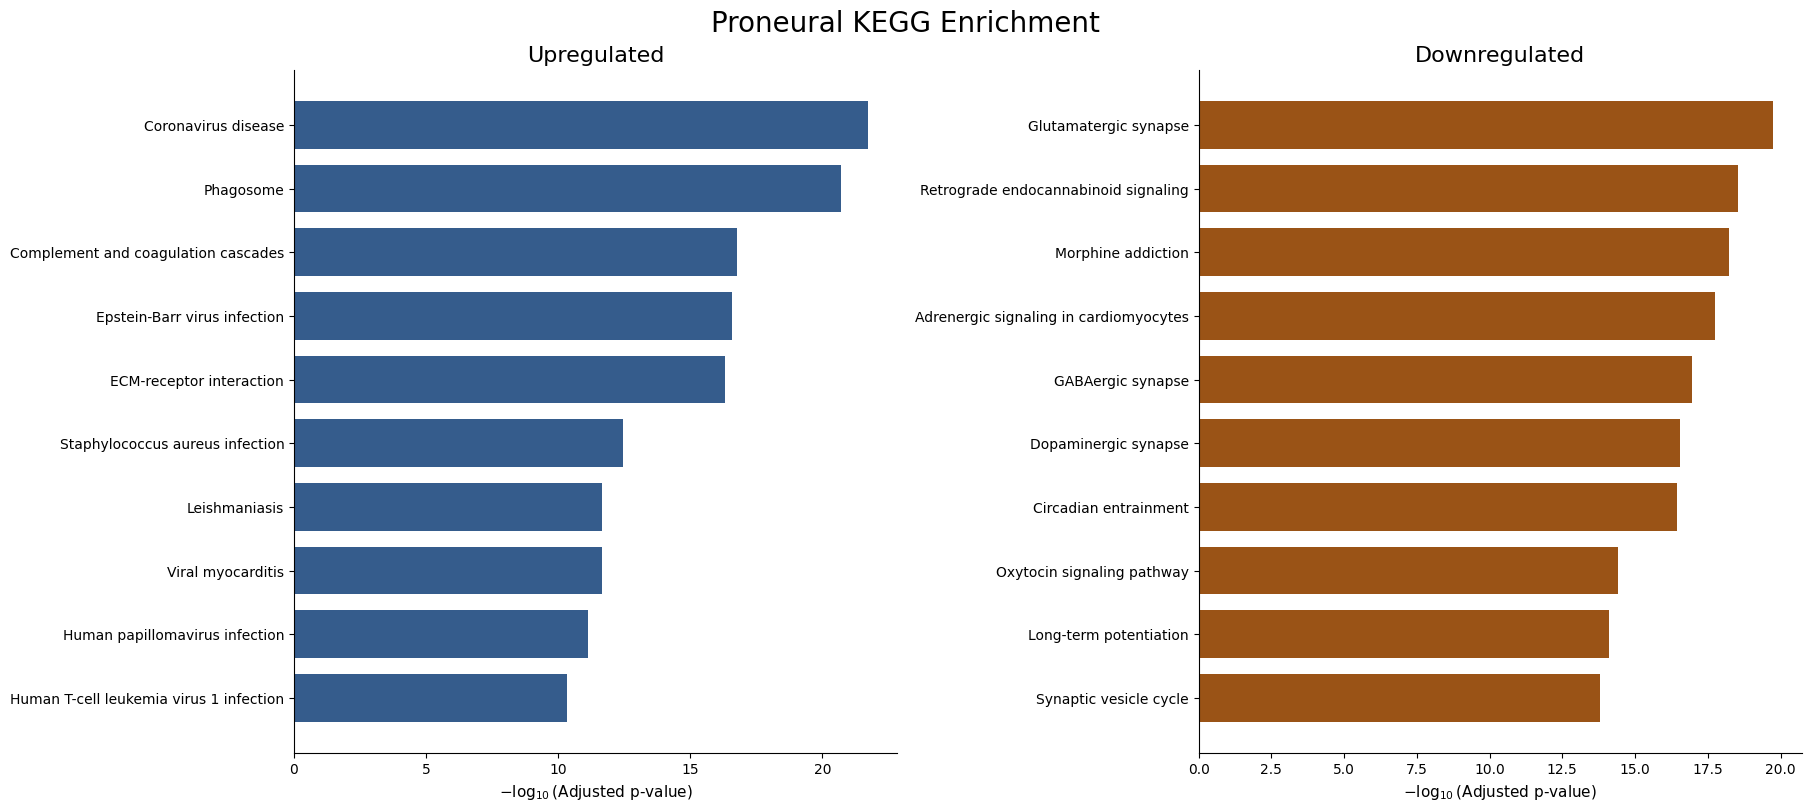

Classical: KEGG UP
Classical: KEGG DOWN


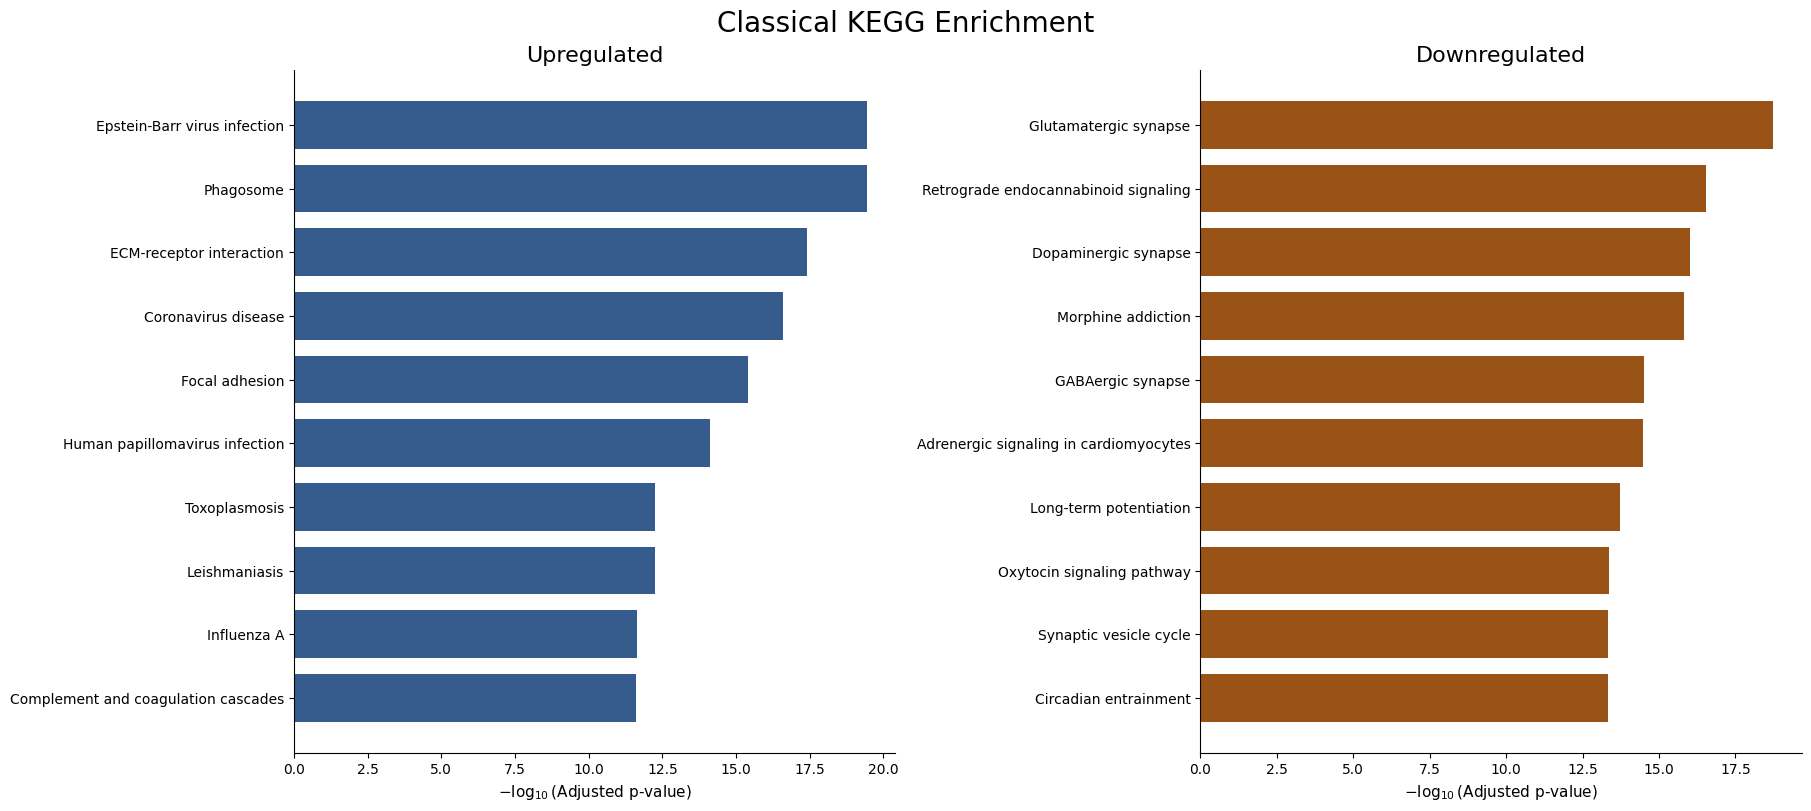

Mesenchymal: KEGG UP
Mesenchymal: KEGG DOWN


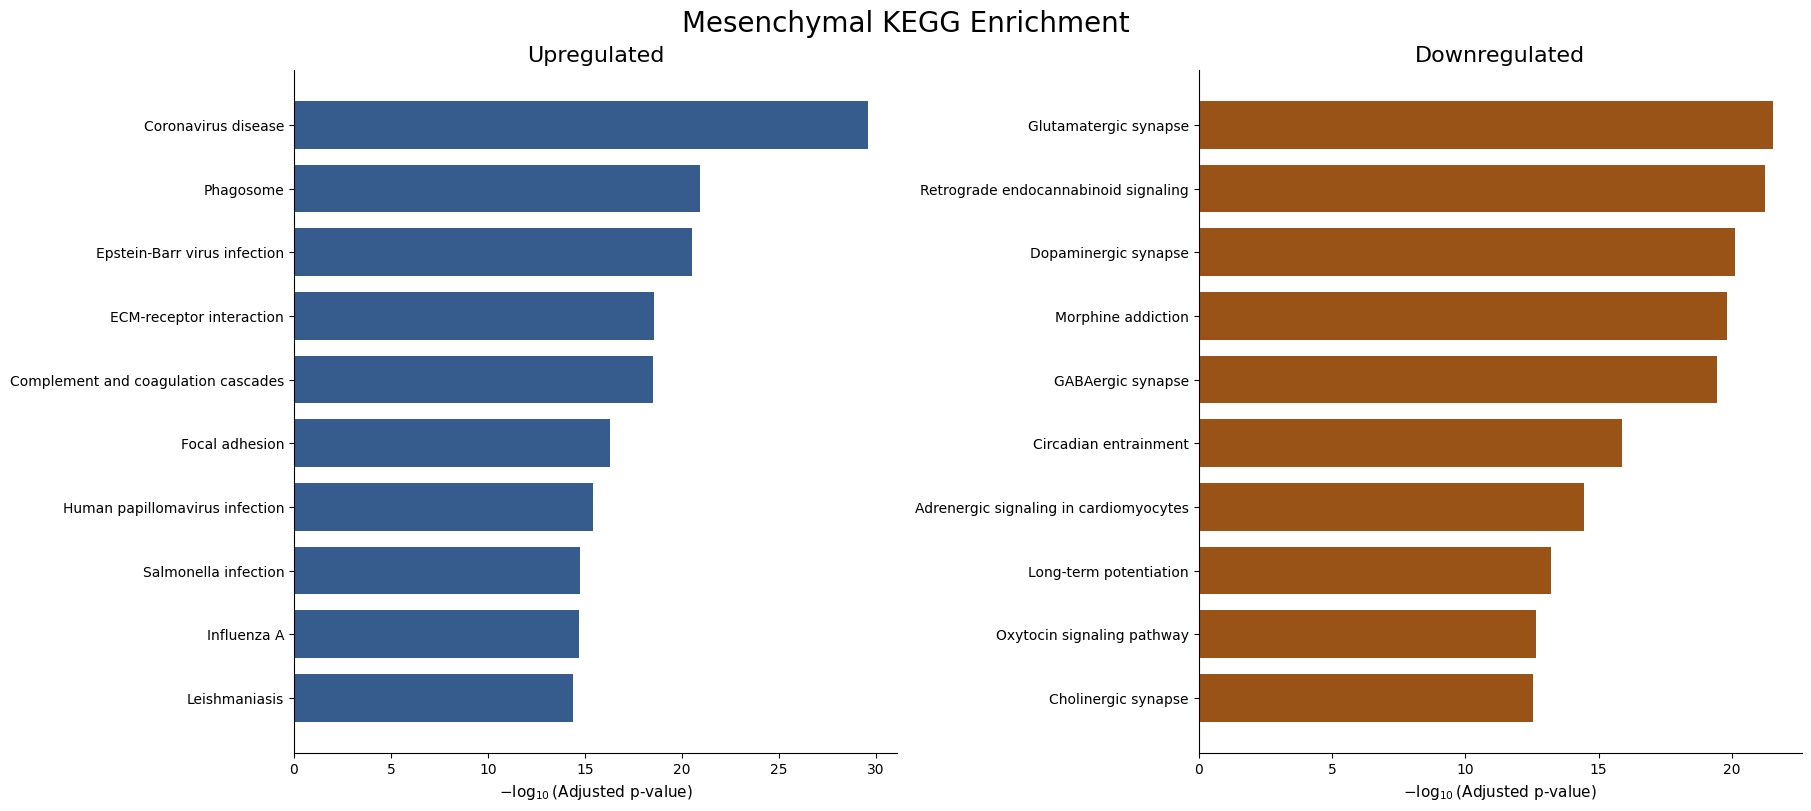

IDH: KEGG UP
IDH: KEGG DOWN


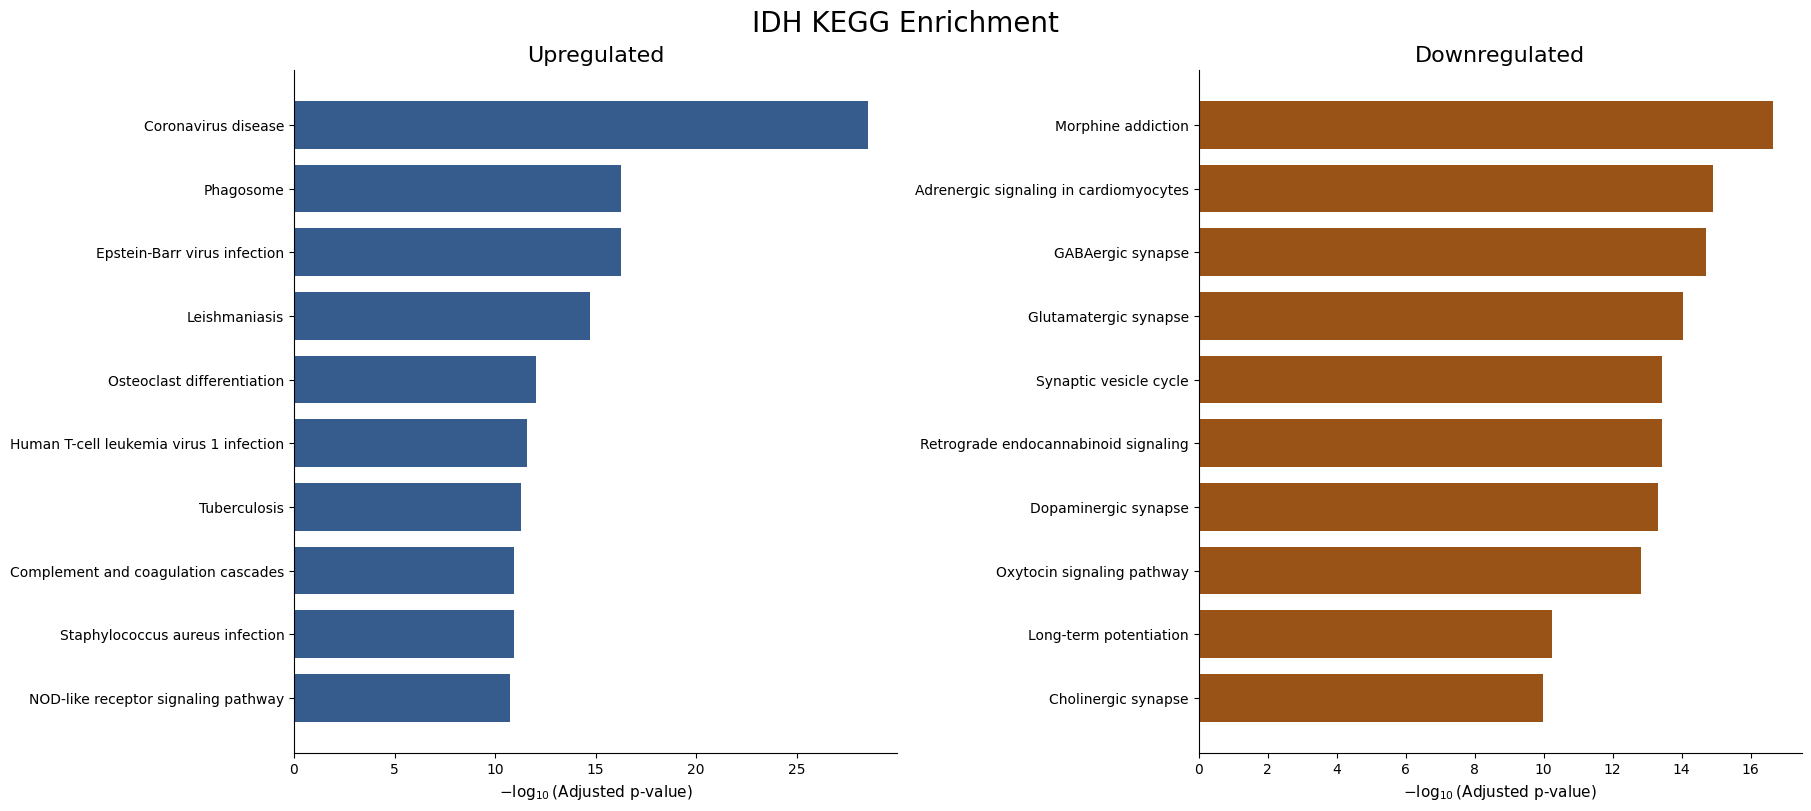

In [30]:
files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv",
    "IDH": "../data/interim/idh_rna_diff.csv"
}

for subtype, file in files.items():
    analyze_subtype_kegg(file, subtype)